In [52]:

import pandas as pd 
from sklearn.preprocessing import StandardScaler,LabelEncoder
from keras.layers import Dense,Input,BatchNormalization
from keras.regularizers import L1,L2,L1L2
from keras.callbacks import EarlyStopping
from keras.models import Sequential
from sklearn.model_selection import train_test_split
import tensorflow
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score


In [21]:
df = pd.read_csv("Churn_Modelling.csv")
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [22]:
le_gender = LabelEncoder()
df["Gender"] = le_gender.fit_transform(df["Gender"])

df = pd.get_dummies(df,columns = ["Geography"],drop_first = True)
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,1,15634602,Hargrave,619,0,42,2,0.00,1,1,1,101348.88,1,False,False
1,2,15647311,Hill,608,0,41,1,83807.86,1,0,1,112542.58,0,False,True
2,3,15619304,Onio,502,0,42,8,159660.80,3,1,0,113931.57,1,False,False
3,4,15701354,Boni,699,0,39,1,0.00,2,0,0,93826.63,0,False,False
4,5,15737888,Mitchell,850,0,43,2,125510.82,1,1,1,79084.10,0,False,True


In [23]:
x = df.drop(columns=["Exited","RowNumber","CustomerId","Surname"])
y = df["Exited"]
x.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,False,False
3,699,0,39,1,0.00,2,0,0,93826.63,False,False
4,850,0,43,2,125510.82,1,1,1,79084.10,False,True


In [24]:
ss = StandardScaler()
x = ss.fit_transform(x)
x

array([[-0.32622142, -1.09598752,  0.29351742, ...,  0.02188649,
        -0.57873591, -0.57380915],
       [-0.44003595, -1.09598752,  0.19816383, ...,  0.21653375,
        -0.57873591,  1.74273971],
       [-1.53679418, -1.09598752,  0.29351742, ...,  0.2406869 ,
        -0.57873591, -0.57380915],
       ...,
       [ 0.60498839, -1.09598752, -0.27860412, ..., -1.00864308,
        -0.57873591, -0.57380915],
       [ 1.25683526,  0.91241915,  0.29351742, ..., -0.12523071,
         1.72790383, -0.57380915],
       [ 1.46377078, -1.09598752, -1.04143285, ..., -1.07636976,
        -0.57873591, -0.57380915]])

In [25]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=10
)

In [77]:
ann = Sequential([
    Input(shape=(11,)),
    Dense(6, activation="relu", kernel_regularizer=L2(0.01)),
    BatchNormalization(),
    Dense(4, activation="relu", kernel_regularizer=L2(0.01)),
    BatchNormalization(),
    Dense(2, activation="relu", kernel_regularizer=L2(0.01)),
    BatchNormalization(),
    Dense(1, activation="sigmoid")])

In [78]:
ann.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [79]:
print(x_train.shape)

(8000, 11)


In [80]:
ann.fit(x_train, y_train, epochs=50, batch_size=200,validation_data = (x_test,y_test),callbacks=EarlyStopping())

Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.4812 - loss: 0.9696 - val_accuracy: 0.7425 - val_loss: 0.7680
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5305 - loss: 0.8882 - val_accuracy: 0.7430 - val_loss: 0.7650
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6036 - loss: 0.8221 - val_accuracy: 0.7410 - val_loss: 0.7523
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6779 - loss: 0.7688 - val_accuracy: 0.7470 - val_loss: 0.7371
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7291 - loss: 0.7253 - val_accuracy: 0.7500 - val_loss: 0.7183
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7560 - loss: 0.6904 - val_accuracy: 0.7550 - val_loss: 0.6958
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7705 - loss: 0.6589 - val_accuracy: 0.7675 - val_loss: 0.6688
Epoch 8/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7805 - loss: 0.6306 - val_accuracy: 0.7750 - val_loss

In [81]:
train_accuracy = ann.history.history["accuracy"]
test_accuracy = ann.history.history["val_accuracy"]

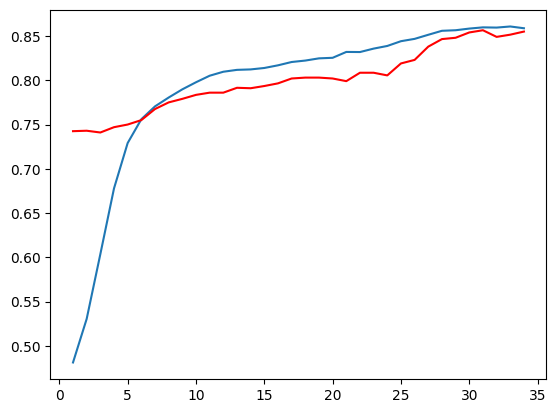

In [82]:
plt.plot([i for i in range(1,35)],train_accuracy)
plt.plot([i for i in range(1,35)],test_accuracy,c = "red")
plt.show()

In [83]:
prd1 = ann.predict(x_train)
prd1_data = []
for i in prd1:
    if i[0] > 0.5:
        prd1_data.append(1)
    else:
        prd1_data.append(0)

250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [84]:
prd2 = ann.predict(x_test)
prd2_data = []
for i in prd2:
    if i[0] > 0.5:
        prd2_data.append(1)
    else:
        prd2_data.append(0)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [85]:
acc1 = accuracy_score(y_test, prd2_data)

In [86]:
print("Accuracy:", round(acc1 * 100, 2), "%")

Accuracy: 85.5 %


In [87]:
acc2 = accuracy_score(y_train,prd1_data)

In [88]:
print("Accuracy:", round(acc2 * 100, 2), "%")

Accuracy: 86.25 %
